# Deep Learning

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

## Computer Vision

### CNN

In [3]:

# Load MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Normalize pixel values
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Add channel dimension for CNNs
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

print("Training images:", train_images.shape)
print("Training labels:", train_labels.shape)
print("Test images:", test_images.shape)
print("Test labels:", test_labels.shape)

Training images: (60000, 28, 28, 1)
Training labels: (60000,)
Test images: (10000, 28, 28, 1)
Test labels: (10000,)


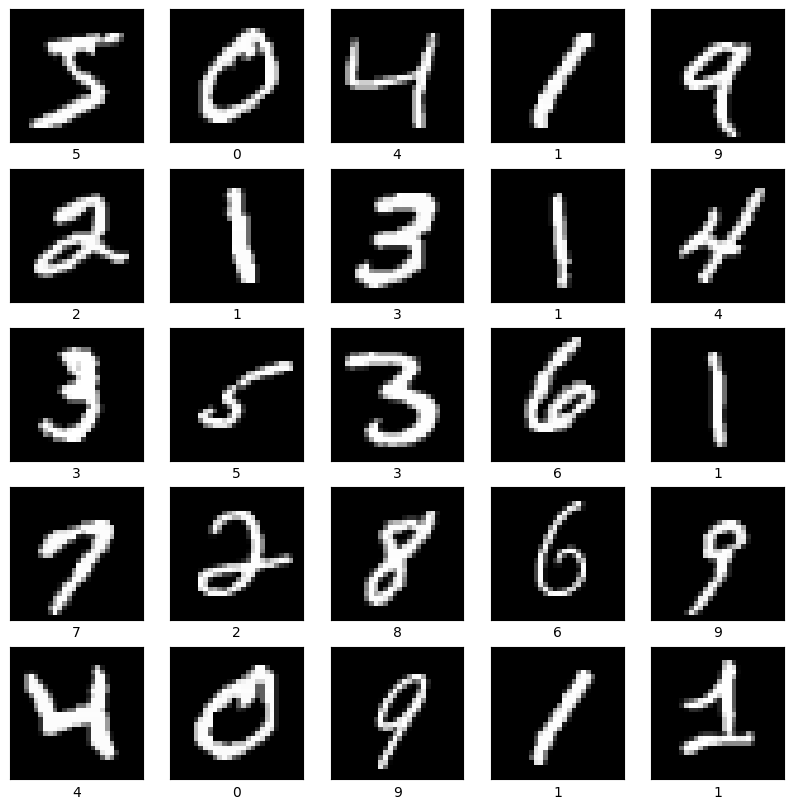

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(train_images[i].squeeze(), cmap='gray')

    plt.xlabel(train_labels[i])
plt.show()

In [5]:
from tensorflow.keras import models, layers

model = models.Sequential()

model.add(layers.Input(shape=(28, 28, 1)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))  # 10 output classes (digits 0-9)

In [6]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

history = model.fit(train_images, train_labels, epochs=3, 
                    validation_data=(test_images, test_labels))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9561 - loss: 0.1423 - val_accuracy: 0.9832 - val_loss: 0.0530
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9863 - loss: 0.0461 - val_accuracy: 0.9900 - val_loss: 0.0320
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9895 - loss: 0.0337 - val_accuracy: 0.9913 - val_loss: 0.0288


313/313 - 1s - 2ms/step - accuracy: 0.9913 - loss: 0.0288


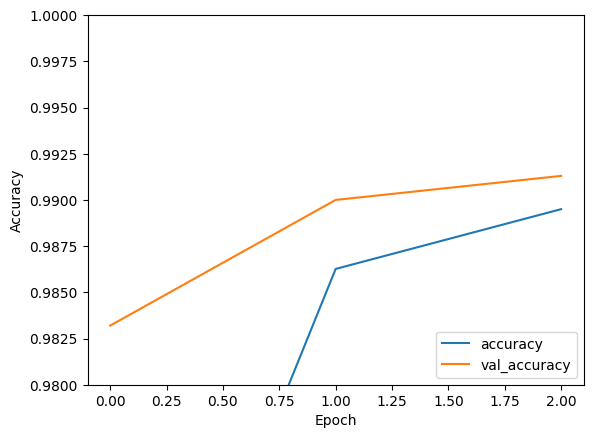

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.98, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

## NLP

###  NLP Data



In [14]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_length = 200

(X_train_full, y_train_full), (X_test_full, y_test_full) = imdb.load_data(num_words=vocab_size)

# Smaller subset shared across LSTM, GRU, and BERT
N_TRAIN_NLP = 2000
N_TEST_NLP = 500

X_train_raw = X_train_full[:N_TRAIN_NLP]
y_train = y_train_full[:N_TRAIN_NLP]
X_test_raw = X_test_full[:N_TEST_NLP]
y_test = y_test_full[:N_TEST_NLP]

X_train = pad_sequences(X_train_raw, maxlen=max_length)
X_test = pad_sequences(X_test_raw, maxlen=max_length)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (2000, 200)
y_train: (2000,)
X_test : (500, 200)
y_test : (500,)


### LSTM

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(vocab_size, 300, input_length=max_length),
    LSTM(256),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/2


/home/sreekar/nemotron/venv/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.5665 - loss: 0.6855 - val_accuracy: 0.7060 - val_loss: 0.5832
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.7650 - loss: 0.5129 - val_accuracy: 0.6520 - val_loss: 0.6264


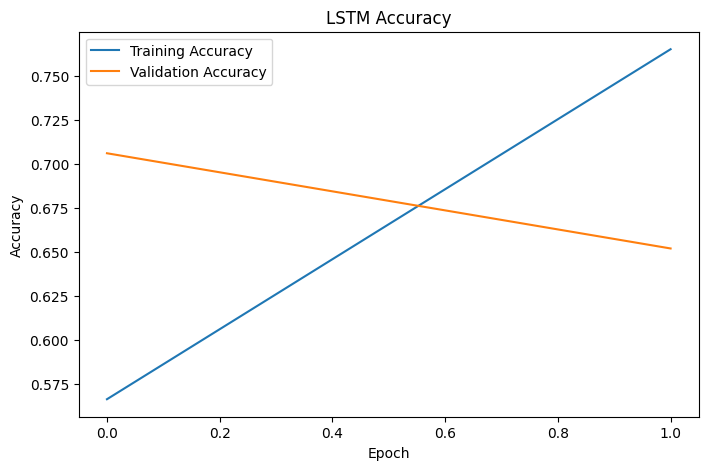

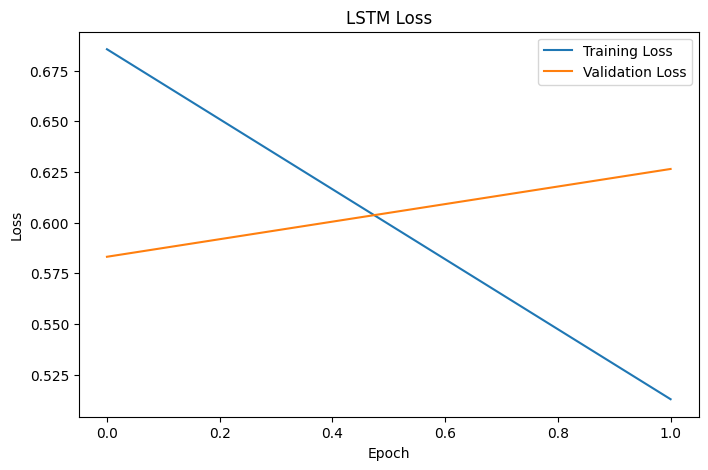

In [16]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(lstm_history.history['accuracy'], label='Training Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss')
plt.legend()
plt.show()

### GRU

Uses the **same** `X_train` / `y_train` / `X_test` / `y_test` defined in the shared NLP data cell above.

In [17]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(vocab_size, 300, input_length=max_length),
    GRU(256),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=2,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 269ms/step - accuracy: 0.5550 - loss: 0.6808 - val_accuracy: 0.6320 - val_loss: 0.8925
Epoch 2/2
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.7380 - loss: 0.5629 - val_accuracy: 0.6140 - val_loss: 0.6301


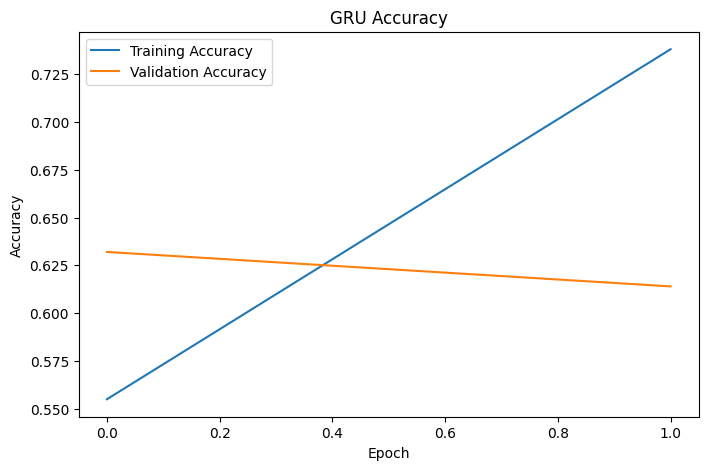

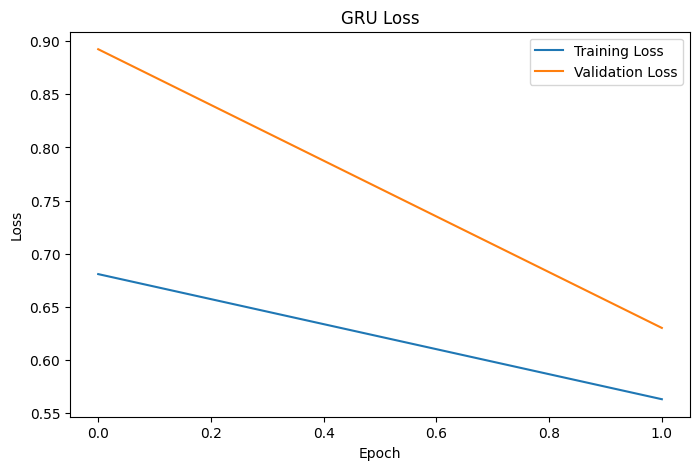

In [18]:
# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(gru_history.history['accuracy'], label='Training Accuracy')
plt.plot(gru_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('GRU Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(gru_history.history['loss'], label='Training Loss')
plt.plot(gru_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GRU Loss')
plt.legend()
plt.show()

### BERT

In [19]:
from transformers import pipeline

# Decode the same IMDB reviews (from the shared subset) back to text for BERT
word_index = imdb.get_word_index()
reverse_word_index = {v + 3: k for k, v in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(encoded_review):
    return " ".join(reverse_word_index.get(i, "?") for i in encoded_review)

# Small sample pulled from the SAME shared test subset (X_test_raw / y_test)
sample_texts = [decode_review(review) for review in X_test_raw[:5]]
sample_labels = y_test[:5]

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

for text, label in zip(sample_texts, sample_labels):
    result = classifier(text[:512])  # truncate to the model's max input length
    true_label = "positive" if label == 1 else "negative"
    print(f"True label: {true_label} | Predicted: {result}")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Loading weights: 100%|██████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 2255.26it/s]
/home/sreekar/nemotron/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 302: Error loading CUDA libraries. GPU will not be used. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


True label: negative | Predicted: [{'label': 'NEGATIVE', 'score': 0.9997134804725647}]
True label: positive | Predicted: [{'label': 'POSITIVE', 'score': 0.9978511333465576}]
True label: positive | Predicted: [{'label': 'POSITIVE', 'score': 0.9959088563919067}]
True label: negative | Predicted: [{'label': 'NEGATIVE', 'score': 0.9860240817070007}]
True label: positive | Predicted: [{'label': 'POSITIVE', 'score': 0.999708354473114}]
